In [1]:
# Project root setup
import os
import sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)


In [2]:
import importlib

import numpy as np
import pandas as pd
from IPython.display import Image, display

import synthetic.scripts.different_vars as dv

# Reload so notebook changes pick up the latest script version and current baselines.
dv = importlib.reload(dv)


/home/srey/Investigacion/cvx_dag_learning/.venv-dag/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Notebook controls. These override the defaults in synthetic/scripts/different_vars.py.
LOAD = True  # Set to False to rerun from the notebook.
SAVE = False
N_CPUS = dv.N_CPUS
JOBLIB_VERBOSE = dv.JOBLIB_VERBOSE

N_DAGS = dv.N_DAGS
THR = dv.THR
VERB = dv.VERB
VAR_VALUES = dv.VAR_VALUES
BASE_DATA_PARAMS = dv.BASE_DATA_PARAMS.copy()
HETERO_VAR_RANGE = dv.HETERO_VAR_RANGE
JOINT_AGGS = dv.JOINT_AGGS
SELECTED_EXPERIMENT_LEGS = dv.SELECTED_EXPERIMENT_LEGS
SKIP_IDX = []  # Example: [2, 5] skips DAGMA and CoLiDE-NV.

# Push notebook controls back into the script module used below.
dv.LOAD = LOAD
dv.SAVE = SAVE
dv.N_CPUS = N_CPUS
dv.JOBLIB_VERBOSE = JOBLIB_VERBOSE
dv.HETERO_VAR_RANGE = HETERO_VAR_RANGE
dv.SKIP_IDX = SKIP_IDX


In [4]:
def display_png(path):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"Missing figure: {path}")


def display_scenario_figures(suffix):
    display_png(Path(dv.PATH) / f"vars_{suffix}_summary_mean.png")
    display_png(Path(dv.PATH) / f"vars_{suffix}_summary_median.png")
    display_png(Path(dv.PATH) / f"vars_{suffix}_all_metrics_mean.png")
    display_png(Path(dv.PATH) / f"vars_{suffix}_all_metrics_median.png")


def display_joint_figures(aggs=JOINT_AGGS):
    for agg in aggs:
        display_png(Path(dv.PATH) / f"vars_hom_hetero_joint_{agg}.png")


def scenario_result(scenario, metrics, exps, var_values):
    return {
        "scenario": scenario,
        "metrics": metrics,
        "exps": exps,
        "var_values": var_values,
    }


def metric_summary(metrics, exps, var_values):
    shd, _, _, _, err, acyc, runtime, _ = metrics
    rows = []
    for j, exp in enumerate(exps):
        for i, var in enumerate(var_values):
            rows.append({
                "variance": var,
                "method": exp["leg"],
                "err_mean": np.mean(err[:, i, j]),
                "err_median": np.median(err[:, i, j]),
                "shd_mean": np.mean(shd[:, i, j]),
                "shd_median": np.median(shd[:, i, j]),
                "acyc_mean": np.mean(acyc[:, i, j]),
                "time_mean": np.mean(runtime[:, i, j]),
            })
    return pd.DataFrame(rows)


In [5]:
Exps = dv.filter_experiments(dv.build_experiments(), SELECTED_EXPERIMENT_LEGS)
vars = np.asarray(VAR_VALUES)
scenarios = dv.build_scenarios(BASE_DATA_PARAMS)

hom_scenario = scenarios[0]
hetero_scenario = scenarios[1]

print("Scenarios:", [scenario["name"] for scenario in scenarios])
print("Baselines:")
for i, exp in enumerate(Exps):
    skipped = " (skipped)" if i in SKIP_IDX else ""
    print(f"  {i}: {exp['leg']}{skipped}")
print("Variance grid:", vars)
print("Mode:", "load" if LOAD else "run")


Scenarios: ['homocedastic', 'heterocedastic']
Baselines:
  0: NOMAD-adam
  1: NOMAD-fista
  2: DAGMA
  3: NonDAGMA
  4: CoLiDE-EV
  5: CoLiDE-NV
  6: GOLEM-EV
  7: GOLEM-NV
Variance grid: [ 1  5 10 20 30]
Mode: load


## Homocedastic Scenario


Loaded variance results from /home/srey/Investigacion/cvx_dag_learning/results/var/var_hom_ERgraph_4N.npz


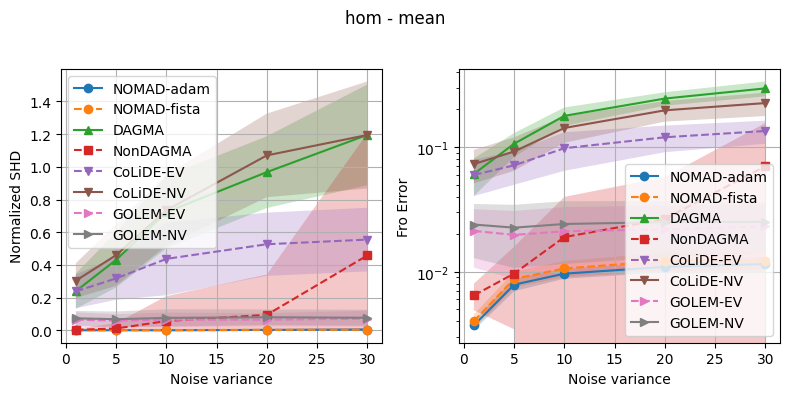

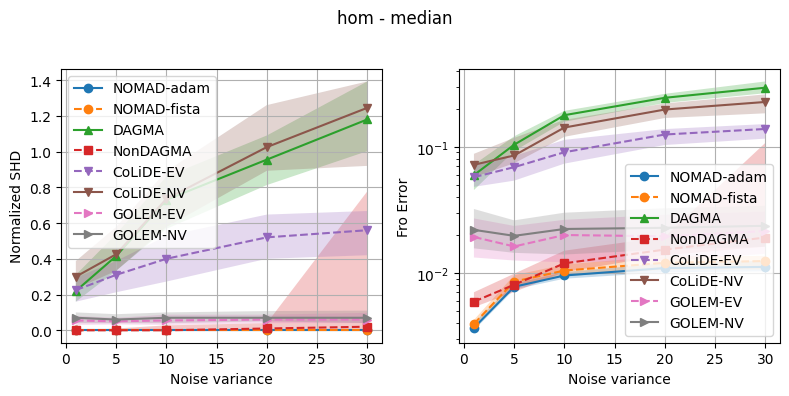

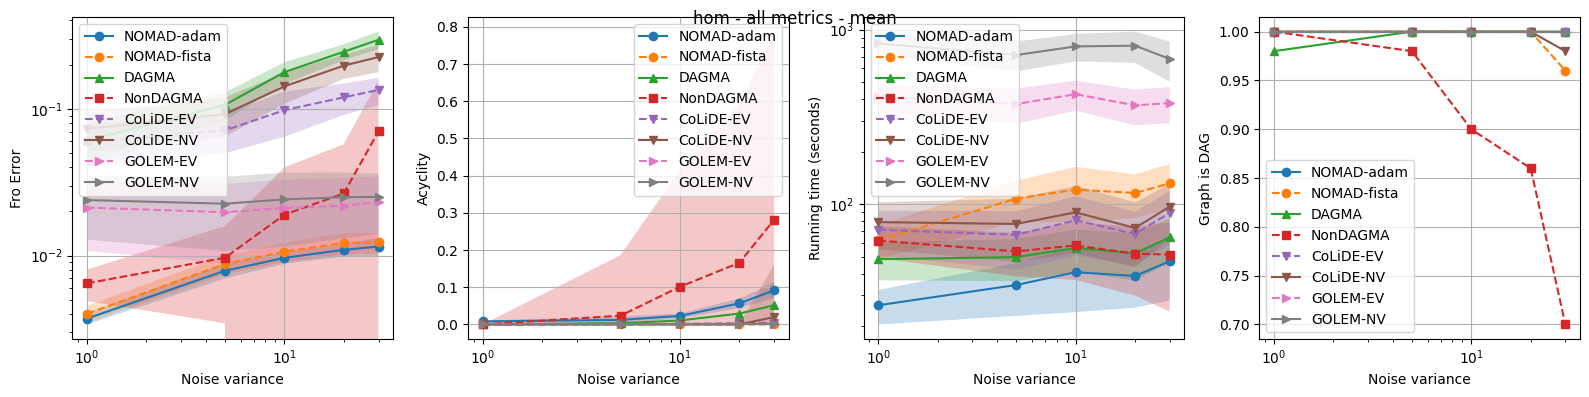

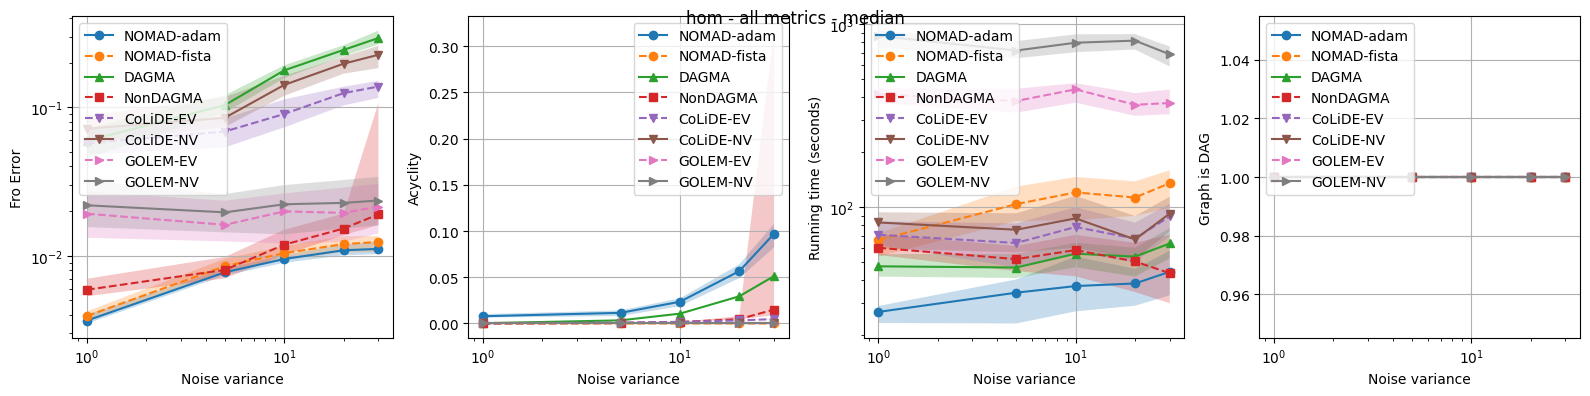

In [ ]:
*hom_metrics, hom_exps, hom_vars = dv.run_or_load_vars_results(
    hom_scenario,
    vars,
    Exps,
    N_DAGS,
    thr=THR,
    verb=VERB,
)

skip_idx = []
skip_idx = [1, 5, 7]

dv.plot_results(hom_metrics, hom_exps, hom_vars, hom_scenario["suffix"], skip_idx=skip_idx)
hom_result = scenario_result(hom_scenario, hom_metrics, hom_exps, hom_vars)

display_scenario_figures(hom_scenario["suffix"])


## Heterocedastic Scenario


Loaded variance results from /home/srey/Investigacion/cvx_dag_learning/results/var/var_hetero_ERgraph_4N.npz


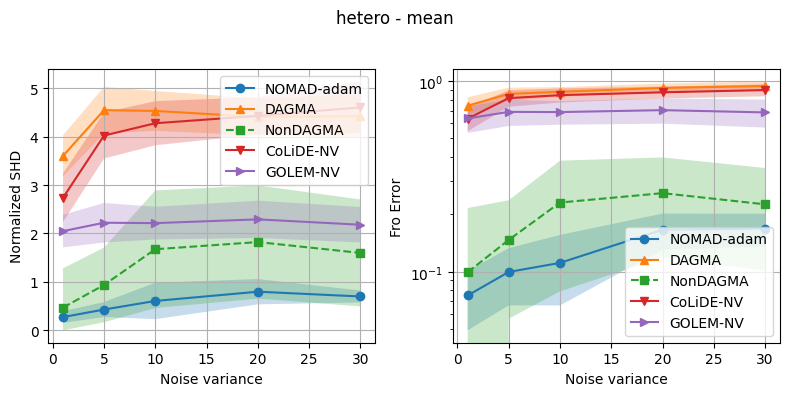

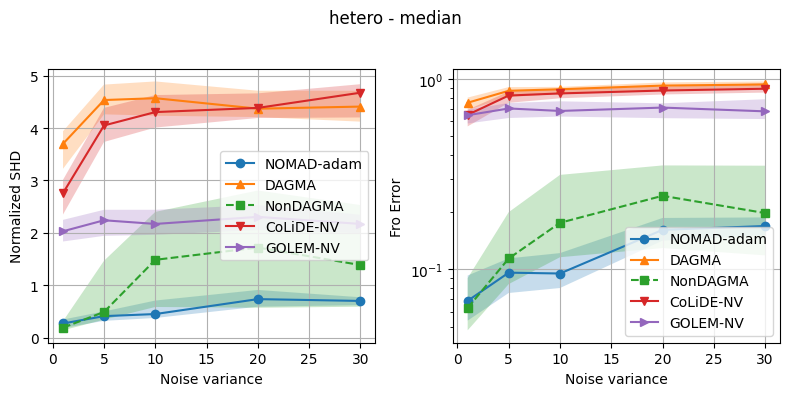

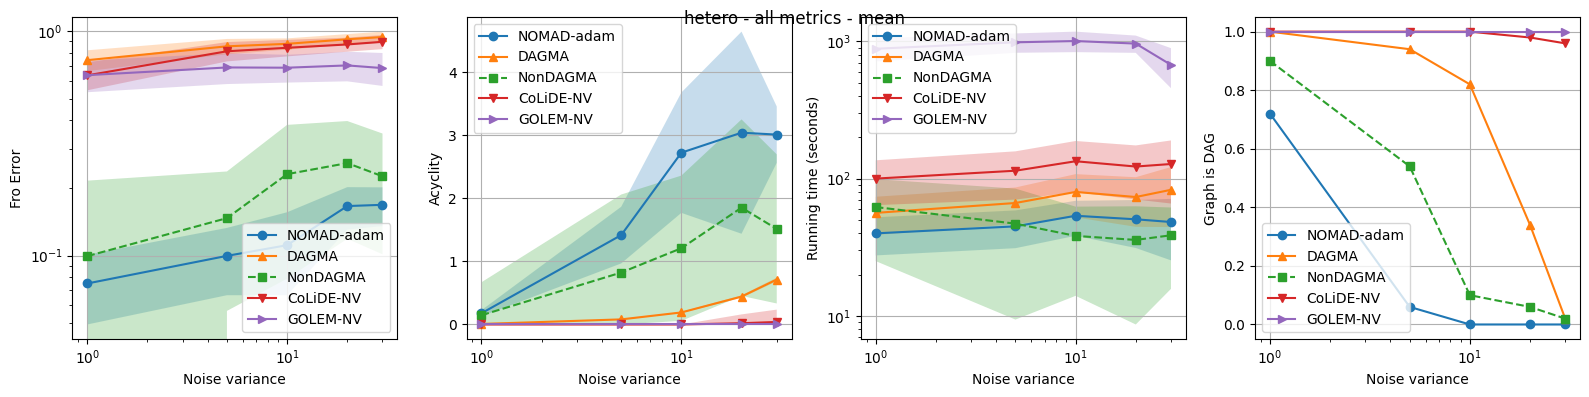

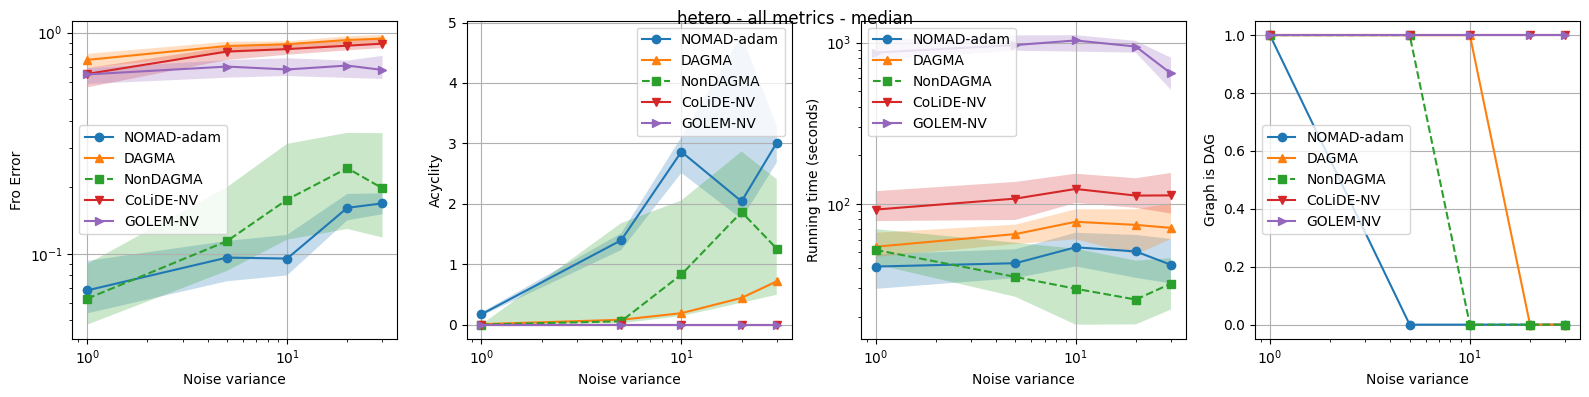

In [7]:
*hetero_metrics, hetero_exps, hetero_vars = dv.run_or_load_vars_results(
    hetero_scenario,
    vars,
    Exps,
    N_DAGS,
    thr=THR,
    verb=VERB,
)

skip_idx = []
skip_idx = [1, 4, 6]

dv.plot_results(hetero_metrics, hetero_exps, hetero_vars, hetero_scenario["suffix"], skip_idx=skip_idx)
hetero_result = scenario_result(hetero_scenario, hetero_metrics, hetero_exps, hetero_vars)
display_scenario_figures(hetero_scenario["suffix"])


## Joint Figures


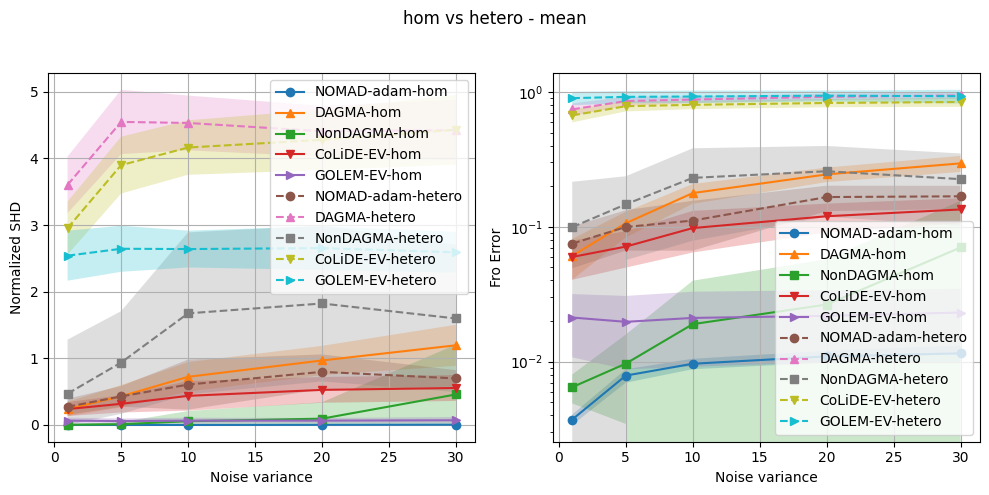

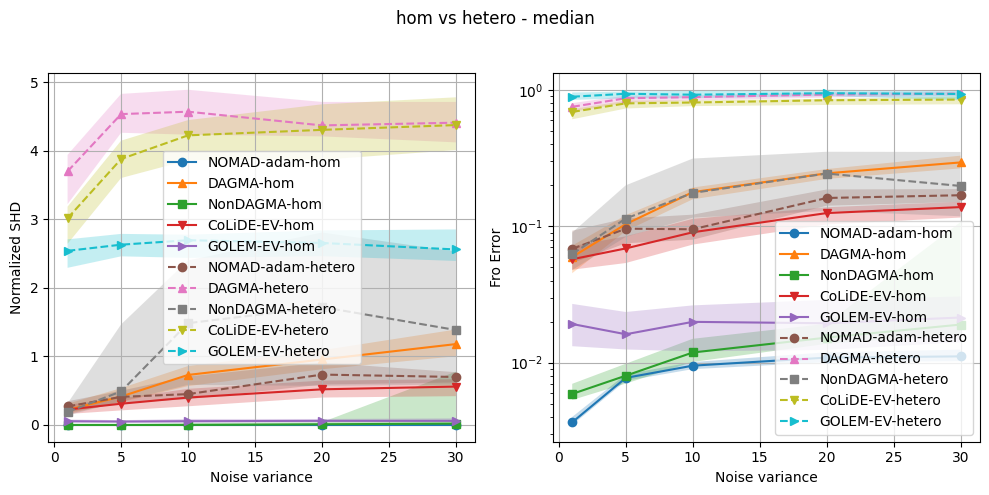

In [8]:
scenario_results = [hom_result, hetero_result]

SKIP_IDX = [1,5,7,11]

for agg in JOINT_AGGS:
    dv.plot_joint_results(scenario_results, agg=agg, skip_idx=SKIP_IDX)

display_joint_figures(JOINT_AGGS)


## Optional Tables


In [9]:
hom_summary = metric_summary(hom_metrics, hom_exps, hom_vars)
hetero_summary = metric_summary(hetero_metrics, hetero_exps, hetero_vars)

display(hom_summary)
display(hetero_summary)


,variance,method,err_mean,err_median,shd_mean,shd_median,acyc_mean,time_mean
0,1,NOMAD-adam,0.003722,0.003658,0.0000,0.000,0.008258,26.299147
1,5,NOMAD-adam,0.007881,0.007738,0.0004,0.000,0.012363,34.378788
2,10,NOMAD-adam,0.009647,0.009510,0.0000,0.000,0.023100,40.700306
3,20,NOMAD-adam,0.010944,0.010893,0.0022,0.000,0.056829,38.713389
4,30,NOMAD-adam,0.011518,0.011125,0.0040,0.000,0.091795,47.091049
5,1,NOMAD-fista,0.004016,0.003929,0.0004,0.000,0.000025,61.978755
6,5,NOMAD-fista,0.008761,0.008506,0.0004,0.000,0.000027,107.480464
7,10,NOMAD-fista,0.010618,0.010409,0.0012,0.000,0.000024,121.011624
8,20,NOMAD-fista,0.012192,0.011990,0.0026,0.000,0.000042,115.719707
9,30,NOMAD-fista,0.012282,0.012376,0.0036,0.000,0.000043,131.444081


,variance,method,err_mean,err_median,shd_mean,shd_median,acyc_mean,time_mean
0,1,NOMAD-adam,0.075069,0.068300,0.2728,0.270,1.780104e-01,39.975197
1,5,NOMAD-adam,0.099689,0.096059,0.4286,0.410,1.418604e+00,44.965417
2,10,NOMAD-adam,0.111249,0.095078,0.6062,0.450,2.727135e+00,53.708494
3,20,NOMAD-adam,0.166184,0.161297,0.7970,0.735,3.044384e+00,50.607560
4,30,NOMAD-adam,0.168339,0.168964,0.6984,0.700,3.014055e+00,48.363438
5,1,NOMAD-fista,0.152074,0.152079,0.5192,0.555,1.548233e-05,106.868967
6,5,NOMAD-fista,0.156555,0.162089,0.5766,0.575,3.102585e-05,141.140871
7,10,NOMAD-fista,0.161551,0.168106,0.5992,0.635,4.627849e-05,167.658755
8,20,NOMAD-fista,0.160581,0.172874,0.5670,0.585,3.234453e-05,163.672114
9,30,NOMAD-fista,0.154292,0.167139,0.5736,0.610,7.555284e-05,172.276143
